In [1]:
#Import required libraries:
import pandas as pd
import numpy as np
from linearmodels.iv import AbsorbingLS
from statsmodels.iolib.summary2 import summary_col
import matplotlib.pyplot as plt

In [2]:
# Load data:
master_df = pd.read_parquet('data/flight_data.parquet')

In [3]:
# Define outcome variables:
# - Flight departure is delayed 15+ minutes (delay_gt_15)
# - Flight departure is delayed 30+ minutes (delay_gt_15)
# - Flight departure is delayed 60+ minutes (delay_gt_15)
# - Flight departure is delayed 120+ minutes (delay_gt_15)
# - Flight departure delay in minutes (departure_delay_minutes)
for t in [15, 30, 60, 120]:
    master_df[f'delay_gt_{t}'] = (master_df['departure_delay_minutes'] > t).astype(int)
OUTCOMES = ['delay_gt_15', 'delay_gt_30', 'delay_gt_60', 'delay_gt_120', 'departure_delay_minutes']


# Define treatment variables (event study variable engineering):
# Treatment variables are binaries equal to 1 if the flight is:
#     - (1) is greater than l hours but less than u hours from the effective timing of the srike incident (ETS) and;
#     - (2) operated by the same airline to which the strike occured
# These indicators measure both the treatment status (same as strike airline) and time distance, in four hour intervals, from the ETS.
#    - Negative = Pre-strike (e.g., lead_12 = 1 indicates that the flight is operated by the strike airline and was scheduled to depart [-48 hours,-44 hours) before the ETS)
#    - Positive = Post-strike (e.g., lag_5 = 1 indicates that the flight is operated by the strike airline and was scheduled to depart (16 hours, 20 hours] after the ETS)
master_df['scheduled_departure_datetime'] = pd.to_datetime(master_df['scheduled_departure_datetime'], format='mixed')
master_df['strike_date_time'] = pd.to_datetime(master_df['strike_date_time'], format='mixed')
master_df['hours_from_strike'] = (master_df['scheduled_departure_datetime'] - master_df['strike_date_time']).dt.total_seconds() / 3600
master_df['is_strike_airline'] = (master_df['carrier_code'] == master_df['strike_airline']).astype(int)
# Duplicate variables for steamlined syntax in loops:
h = master_df['hours_from_strike']
is_same = master_df['is_strike_airline'] == 1
# Empty list for the names of the treatment variables:
lag_cols = []
lead_cols = []
# Create leads (Pre-Strike 1-12):
for i in range(1, 13):
    col = f'lead{i}'
    master_df[col] = np.where((h < -(i-1)*4) & (h >= -i*4) & is_same, 1, 0)
    lead_cols.append(col)
# Create lags (Post-Strike 1-12):
for i in range(1, 13):
    col = f'lag{i}'
    master_df[col] = np.where((h > (i-1)*4) & (h <= i*4) & is_same, 1, 0)
    lag_cols.append(col)
# List of treatment variables (Removes "lead_1" as reference group):
WITHIN_TREATMENT = lag_cols
CROSS_TREATMENT = lead_cols[1:] + lag_cols


# Define covariate variables:
# - Total number of flights scheduled to depart in that airport-day-hour (congestion)
# -  (temp)
# -  (visibility)
# -  (windspeed)
# -  (precip)
# -  (humidity)
master_df['hour'] = master_df['scheduled_departure_datetime'].dt.hour
master_df['congestion'] = master_df.groupby(['airport', 'date', 'hour'])['airport'].transform('count')
master_df['congestion_sq'] = master_df['congestion']**2
master_df['temp'] = master_df['temp'] + 25
master_df['temp_sq'] = master_df['temp']**2
master_df['windspeed_sq'] = master_df['windspeed']**2
master_df['windgust_dum'] = np.where(master_df['windgust'].isna(), 0, 1)
master_df['precip_sq'] = master_df['precip']**2
master_df['snow_dum'] = np.where(master_df['snow'] > 0, 1, 0)
master_df['snow_dum'] = master_df['snow_dum'].fillna(0)
COVARIATES = ['congestion', 'congestion_sq', 
              'temp', 'temp_sq', 
              'windspeed', 'windspeed_sq', 'windgust_dum', 
              'precip', 'precip_sq', 'snow_dum']


# Define fixed effect variables:
# - Airport-by-airline fixed effects, for the flight's operating airline and airport--e.g.,"DEN_UA" (airport_carrier)
# - Fixed effect for the flight's hour of scheduled departure--e.g.,"16:00" (hour)
# - Fixed effect for the flight's year--e.g.,"2018" (year)
# - Fixed effect for the flight's month--e.g.,"January" (month)
# - Fixed effect for the flight's day of the week--e.g.,"Sunday" (day_of_week)
master_df['airport_carrier'] = master_df['airport'].astype(str) + "_" + master_df['carrier_code'].astype(str)
master_df['year'] = master_df['scheduled_departure_datetime'].dt.year
master_df['month'] = master_df['scheduled_departure_datetime'].dt.month
master_df['day_of_week'] = master_df['scheduled_departure_datetime'].dt.dayofweek
FIXED_EFFECTS = ['airport_carrier', 'hour', 'year', 'month', 'day_of_week']

In [11]:
def get_treatment_effects(damage, arrival_departure, dv):
    """Runs the FE OLS models for a specific subset of the data and outcome variable."""

    print(f"--- Processing: Damage = {damage} | Departure/Arrival = {arrival_departure} | Dep. Var. = {dv} ---")
    
    # Subset data:
    df = master_df[(master_df['strike_damage'] == damage) & (master_df['strike_arrival_departure'] == arrival_departure)].copy()

    # Run within-airline estimator:
    within_results = run_within_airline_event_study(df, dv)

    # Run cross-airline estimator:
    cross_results = run_cross_airline_event_study(df, dv)
    
    # Save results to table:
    dmg_label = "damaging" if damage == 1 else "non_damaging"
    filename = f"results/{dmg_label}_{arrival_departure.lower()}_{dv}.csv"
    save_results(within_results, cross_results, filename)
    
    # Make plot:
    plot_event_study(df, within_results, cross_results, damage, arrival_departure, dv)


In [15]:
def save_results(within_results, cross_results, filename):
    """Manually stacks Within and Cross model results into one CSV."""
    
    def extract_stats(res, model_name):
        # 1. Get main parameters
        df = pd.DataFrame({
            'Coefficient': res.params,
            'Std_Err': res.std_errors,
            'P_Value': res.pvalues
        })
        
        # 2. Get Confidence Intervals (returns a DF with 2 columns)
        ci = res.conf_int()
        df['Lower_CI'] = ci.iloc[:, 0]
        df['Upper_CI'] = ci.iloc[:, 1]
        
        # 3. Add Significance Stars for quick reading in Excel
        df['Sig'] = pd.cut(df['P_Value'], 
                           bins=[0, 0.01, 0.05, 0.1, 1], 
                           labels=['***', '**', '*', ' '],
                           include_lowest=True)
        
        df['Model'] = model_name
        return df

    # Process both
    df_within = extract_stats(within_results, 'Within-Airline')
    df_cross = extract_stats(cross_results, 'Cross-Airline')
    
    # Combine (stack them on top of each other)
    combined = pd.concat([df_within, df_cross])
    
    # Save to CSV
    combined.to_csv(filename)
    print(f"File saved: {filename}")

In [5]:
def run_within_airline_event_study(df, dv):
    """Runs the Within-Airline FE OLS model."""
    
    # Subset data to only include only the flights that are operated by each associated strike airline
    df = df[df['is_strike_airline'] == 1].copy()
    
    # Organize data into dependent and independent (treatment, covariate, and fixed effect) variables:
    dependent_var = df[dv].copy().astype(float)
    independent_vars = df[WITHIN_TREATMENT + COVARIATES].copy().fillna(0)
    fixed_effect_vars = df[FIXED_EFFECTS].copy()
    for col in fixed_effect_vars.columns:
        fixed_effect_vars[col] = fixed_effect_vars[col].astype('category')

    print(f"Running \"Within-Airline Estimator\" on {len(df)} observations...")
    # Estimate FE OLS regression model:
    model = AbsorbingLS(
        dependent=dependent_var,
        exog=independent_vars,
        absorb=fixed_effect_vars
    )

    # Get model results with robust standard errors
    results = model.fit(cov_type='heteroskedastic')

    # Print model summary table:
    print(results.summary)
    
    # Return results:
    return results

In [6]:
def run_cross_airline_event_study(df, dv):
    """Runs the Cross-Airline FE OLS model."""
    
    # Organize data into dependent and independent (treatment, covariate, and fixed effect) variables:
    dependent_var = df[dv].copy().astype(float)
    independent_vars = df[CROSS_TREATMENT + COVARIATES].copy().fillna(0)
    fixed_effect_vars = df[FIXED_EFFECTS].copy()
    for col in fixed_effect_vars.columns:
        fixed_effect_vars[col] = fixed_effect_vars[col].astype('category')

    print(f"Running \"Cross-Airline Estimator\" on {len(df)} observations...")
    # Estimate FE OLS regression model:
    model = AbsorbingLS(
        dependent=dependent_var,
        exog=independent_vars,
        absorb=fixed_effect_vars
    )

    # Get model results with robust standard errors
    results = model.fit(cov_type='heteroskedastic')

    # Print model summary table:
    print(results.summary)
    
    # Return results:
    return results

In [18]:
def plot_event_study(df, within_results, cross_results, damage, arrival_departure, dv):
    """Plots 'Within-Airline' and 'Cross-Airline' effects on the same figure."""

    print(f"Plotting model estimates...")
    
    dmg_label = "Damaging" if damage == 1 else "Non-Damaging"
    baseline_mean = df[(df['is_strike_airline'] == 1) & (df['hours_from_strike'] < 0)][dv].mean()

    # --- 1. Helper Function to Process Results ---
    def process_res(res, timeline):
        params = res.params
        conf = res.conf_int()
        conf.columns = ['lower', 'upper']
        data = []
        
        for var, hour in timeline.items():
            # If the variable is our reference (lead1), force it to 0
            if var == 'lead1':
                data.append({'hour': 0, 'coef': 0, 'lower': 0, 'upper': 0})
            
            # Otherwise, pull from the model results if the variable exists
            elif var in params:
                data.append({
                    'hour': hour, 
                    'coef': params[var], 
                    'lower': conf.loc[var, 'lower'], 
                    'upper': conf.loc[var, 'upper']
                })
        
        return pd.DataFrame(data).sort_values('hour')

    # Define Full Timeline
    full_timeline = {
        **{f'lead{i}': -i * 4 for i in range(12, 0, -1)},
        **{f'lag{i}': i * 4 for i in range(1, 13)}
    }

    # Extract both dataframes
    df_cross = process_res(cross_results, full_timeline)
    df_within = process_res(within_results, full_timeline)

    # --- 2. Create the Plot ---
    fig, ax1 = plt.subplots(figsize=(13, 8))

    # Plot Cross-Airline (Black)
    ax1.fill_between(df_cross['hour'], df_cross['lower'], df_cross['upper'], 
                     color='black', alpha=0.15, label='Cross-Airline 95% CI')
    ax1.plot(df_cross['hour'], df_cross['coef'], 
             marker='o', color='black', linewidth=2, label='Cross-Airline Estimate')

    # Plot Within-Airline (Blue)
    ax1.fill_between(df_within['hour'], df_within['lower'], df_within['upper'], 
                     color='blue', alpha=0.15, label='Within-Airline 95% CI')
    ax1.plot(df_within['hour'], df_within['coef'], 
             marker='s', color='blue', linewidth=2, linestyle='--', label='Within-Airline Estimate')

    # --- 3. Axes & Aesthetics ---
    ax2 = ax1.twinx()
    y1_min, y1_max = ax1.get_ylim()
    ax1.set_ylim(y1_min, y1_max * 1.05) # Headroom for labels
    
    if baseline_mean != 0:
        ax2.set_ylim(ax1.get_ylim()[0] / baseline_mean * 100, ax1.get_ylim()[1] / baseline_mean * 100)

    ax1.axhline(0, color='red', linestyle='-', linewidth=1, alpha=0.5)
    ax1.axvline(0, color='gray', linestyle='--', alpha=0.5)

    title_dv = dv.replace('_', ' ').title()
    ax1.set_title(f'{dmg_label} {arrival_departure} Strike: {title_dv}\nBaseline: {baseline_mean:.4f}', fontsize=14)
    ax1.set_xlabel('Hours Relative to Strike', fontsize=12)
    ax1.set_ylabel('Estimate (Coefficient)', fontsize=12)
    ax2.set_ylabel('Relative Change (%)', fontsize=12)
    
    ax1.legend(loc='upper left', frameon=True)
    ax1.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.show()

--- Processing: Damage = 0 | Departure/Arrival = Arrival | Dep. Var. = departure_delay_minutes ---
Running "Within-Airline Estimator" on 148469 observations...
                            Absorbing LS Estimation Summary                            
Dep. Variable:     departure_delay_minutes   R-squared:                          0.0693
Estimator:                    Absorbing LS   Adj. R-squared:                     0.0672
No. Observations:                   148469   F-statistic:                        834.60
Date:                     Thu, Jan 29 2026   P-value (F-stat):                   0.0000
Time:                             15:15:29   Distribution:                     chi2(22)
Cov. Estimator:            heteroskedastic   R-squared (No Effects):             0.0143
                                             Variables Absorbed:                 322.00
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-va

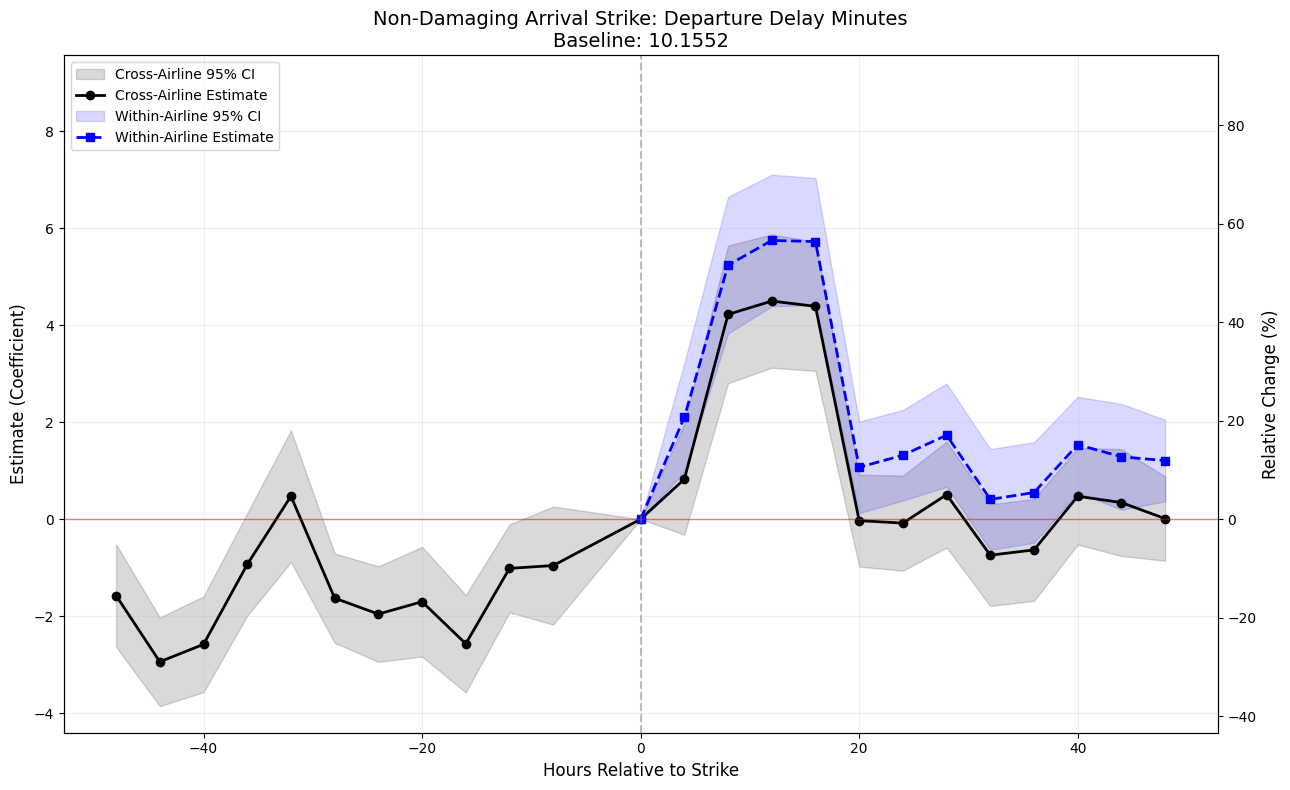

In [16]:
get_treatment_effects(damage=0, arrival_departure="Arrival", dv='departure_delay_minutes')

In [ ]:
get_treatment_effects(damage=1, arrival_departure="Arrival", dv='departure_delay_minutes')

--- Processing: Damage = 0 | Departure/Arrival = Departure | Dep. Var. = departure_delay_minutes ---
Running "Within-Airline Estimator" on 187413 observations...
                            Absorbing LS Estimation Summary                            
Dep. Variable:     departure_delay_minutes   R-squared:                          0.0768
Estimator:                    Absorbing LS   Adj. R-squared:                     0.0754
No. Observations:                   187413   F-statistic:                        791.19
Date:                     Thu, Jan 29 2026   P-value (F-stat):                   0.0000
Time:                             15:21:56   Distribution:                     chi2(22)
Cov. Estimator:            heteroskedastic   R-squared (No Effects):             0.0123
                                             Variables Absorbed:                 253.00
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-

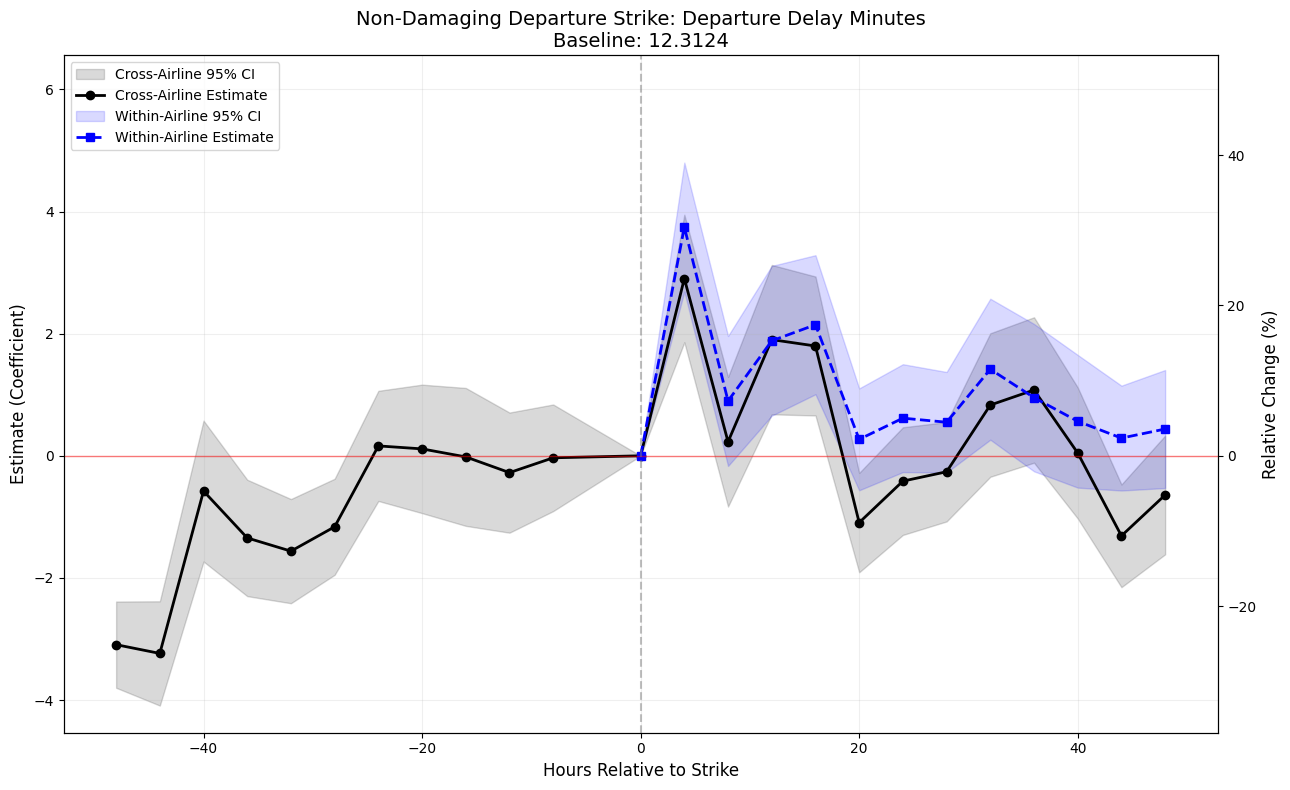

In [17]:
get_treatment_effects(damage=0, arrival_departure="Departure", dv='departure_delay_minutes')

--- Processing: Damage = 1 | Departure/Arrival = Departure | Dep. Var. = departure_delay_minutes ---
Running "Within-Airline Estimator" on 179817 observations...
                            Absorbing LS Estimation Summary                            
Dep. Variable:     departure_delay_minutes   R-squared:                          0.0577
Estimator:                    Absorbing LS   Adj. R-squared:                     0.0562
No. Observations:                   179817   F-statistic:                        794.90
Date:                     Thu, Jan 29 2026   P-value (F-stat):                   0.0000
Time:                             15:24:15   Distribution:                     chi2(22)
Cov. Estimator:            heteroskedastic   R-squared (No Effects):             0.0101
                                             Variables Absorbed:                 264.00
                               Parameter Estimates                               
               Parameter  Std. Err.     T-stat    P-

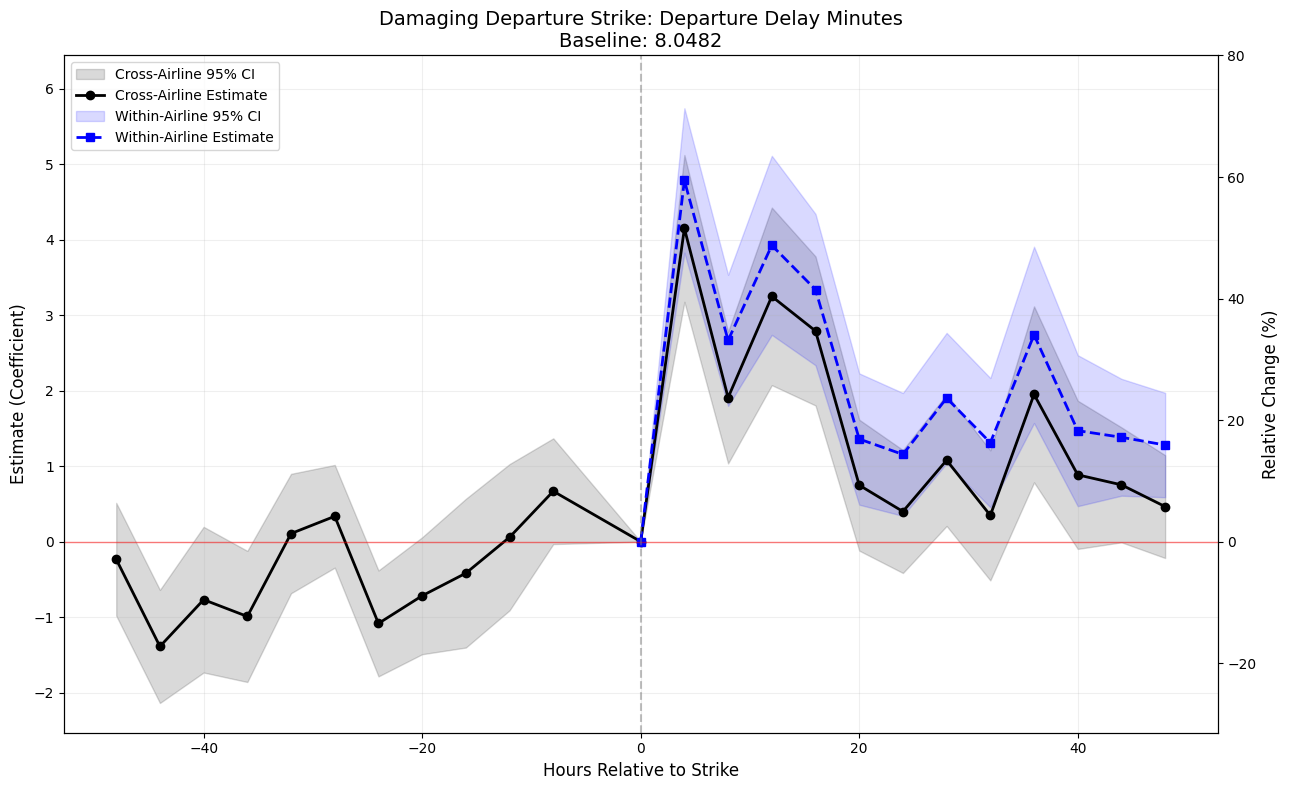

In [19]:
get_treatment_effects(damage=1, arrival_departure="Departure", dv='departure_delay_minutes')